---
title: Letting the fields talk to each other
short_title: 14 · Coregionalization
subtitle: Shared latent processes for the location, scale and shape fields
---

# Does the tail really have no geography?

Notebook 09 gave every GEV parameter its own spatial field and came back with an
uncomfortable answer: $\xi(s)$ carried a signal-to-noise ratio of **0.13**. The
across-station spread of the shape was small next to the uncertainty on any one
station, and the notebook concluded — honestly, on its own evidence — that the
tail's geography was not recoverable.

But that model made an assumption worth questioning. The three fields
$\mu(s)$, $\log\sigma(s)$ and $\xi(s)$ were **independent** GPs. Nothing in it
could express "the places with a high location also have a heavier tail", so
$\xi$ had to be learned from the shape of the maxima alone, at stations with a
few dozen years each. That is close to the hardest possible way to learn a
shape parameter.

**Coregionalization** removes the assumption. Instead of three separate fields we
draw $Q$ shared latent processes $g_q(s)$ and mix them:

$$f_p(s) = \sum_{q=1}^{Q} W_{pq}\, g_q(s), \qquad p \in \{\mu,\ \log\sigma,\ \xi\}$$

The mixing matrix $W$ is learned, so the data decides how much structure the
fields share. This is the linear model of coregionalization, and `pyrox-gp`
provides it as `LMCKernel` / `ICMKernel`.

The question this notebook asks: **was notebook 09's verdict a fact about the
climate, or about its own independence assumption?** The way to find out is to
relax the assumption and see whether the answer moves.

It does not — and the reason it does not turns out to be worth more than a
positive result would have been.


In [1]:
from __future__ import annotations

import time
import warnings

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid", context="notebook")

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_median

from pyrox_gp import (GPPrior, LMCKernel, Matern, MultiOutputGPPrior, gp_sample)
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data, results
from spatial_extremes.features import load_station_features
from spatial_extremes.viz import iberia_axes, scatter_field

In [2]:
maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
S, T = maxima.shape
Y = jnp.asarray(maxima)
mask = jnp.asarray(np.isfinite(maxima))
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
Y_MEAN = float(np.nanmean(maxima))
Xn = jnp.asarray((stations - stations.mean(0)) / stations.std(0))

feat = load_station_features(stations)
_C = feat[["elevation", "dist_coast_km"]].to_numpy()
C = jnp.asarray((_C - _C.mean(0)) / _C.std(0))

_hyp = results.load_fit("gp_primer_hypers", expect_real=is_real)
LENGTHSCALE = float(_hyp["lengthscale"]) if _hyp is not None else 0.8

print("source:", "REAL CDS" if is_real else "synthetic",
      f"| {S} stations | years {years.min()}-{years.max()} ({T})")
print(f"lengthscale {LENGTHSCALE:.2f}"
      f"{' (from notebook 06)' if _hyp is not None else ' (default)'}")

source: REAL CDS | 107 stations | years 1897-2025 (125)
lengthscale 0.91 (from notebook 06)


## What coregionalization actually does

Before fitting anything, it helps to see the mechanism. Below are prior draws
from an `LMCKernel` with two latent processes mixed into three outputs. The
outputs are *different* functions — each has its own shape — but they are no
longer independent: the mixing matrix ties them together, so seeing one tells
you something about the others.

That is the whole idea. The independent model of notebook 09 is the special case
$W = I$, where seeing $\mu$ at a station tells you nothing at all about $\xi$
there.


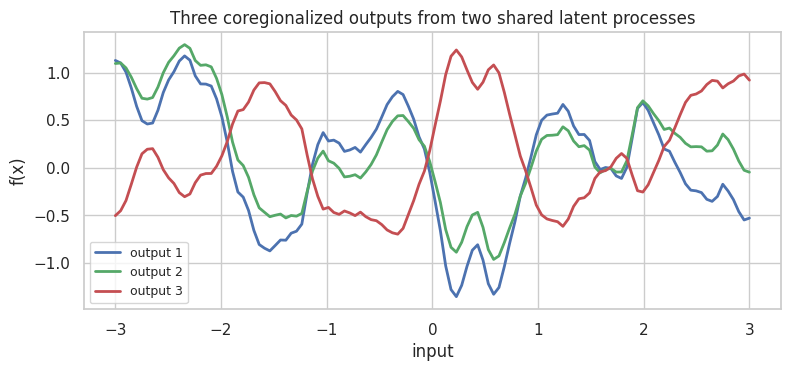

empirical correlation between the three drawn outputs:
[[ 1.    0.92 -0.84]
 [ 0.92  1.   -0.57]
 [-0.84 -0.57  1.  ]]


In [3]:
demo_k = LMCKernel(
    kernels=(Matern(pyrox_name="demo_a", nu=1.5, init_lengthscale=0.6),
             Matern(pyrox_name="demo_b", nu=1.5, init_lengthscale=1.8)),
    mixing=jnp.array([[1.0, 0.2], [0.8, 0.6], [-0.7, 0.5]]),
)
demo_x = jnp.linspace(-3, 3, 120)[:, None]
with numpyro.handlers.seed(rng_seed=0):
    demo_F = np.asarray(MultiOutputGPPrior(kernel=demo_k, X=demo_x).sample(jr.PRNGKey(3)))

fig, ax = plt.subplots(figsize=(9, 3.6))
for p, (lbl, col) in enumerate([("output 1", "#4C72B0"), ("output 2", "#55A868"),
                                ("output 3", "#C44E52")]):
    ax.plot(np.asarray(demo_x).ravel(), demo_F[:, p], lw=2, color=col, label=lbl)
ax.set(xlabel="input", ylabel="f(x)",
       title="Three coregionalized outputs from two shared latent processes")
ax.legend(fontsize=9)
plt.show()

print("empirical correlation between the three drawn outputs:")
print(np.round(np.corrcoef(demo_F.T), 2))

## Two models, one difference

Both models below are notebook 09's, unchanged in every respect except how the
three fields are generated — same likelihood, same covariates, same nuggets,
same priors on the offsets, same inference. Whatever differs in the results is
the sharing and nothing else.

**Independent** (notebook 09): three separate whitened GPs.

**Coregionalized**: $Q=3$ shared latent processes mixed by a learned $W$. Using
$Q=3$ for three outputs keeps $B = WW^{\!\top}$ full rank — with $Q=2$ the
implied correlation matrix is rank-deficient and *forces* a pair of fields to
correlate at exactly $\pm 1$, which would be an artifact of the parameterisation
rather than a fact about Iberia.

The per-output scales `(2.0, 0.3, 0.15)` carry the units — degC for the
location, log units for the scale, tanh pre-image for the shape — so a single
dimensionless $W$ can mix all three.


In [4]:
def gp_field(name, var, Xn):
    """Notebook 09's field: a centred, whitened Matern-3/2 GP."""
    k = Matern(pyrox_name="k_" + name, nu=1.5,
               init_lengthscale=LENGTHSCALE, init_variance=var)
    f = gp_sample("f_" + name, GPPrior(kernel=k, X=Xn), whitened=True)
    return f - jnp.mean(f)


def _shared_block(Xn, Q):
    """Q shared latent processes, mixed into the three parameter fields."""
    G = jnp.stack([gp_field(f"g{q}", 1.0, Xn) for q in range(Q)], axis=-1)  # (S, Q)
    W = numpyro.sample("W", ndist.Normal(0.0, 1.0).expand([3, Q]).to_event(2))
    scale_p = jnp.array([2.0, 0.3, 0.15])        # degC | log units | tanh pre-image
    return (G @ W.T) * scale_p                   # (S, 3)


def make_model(kind, Q=3):
    """`kind` is "independent" (notebook 09) or "coregionalized"."""

    def model(Xn, Y=None):
        if kind == "independent":
            F = jnp.stack([gp_field("mu", 4.0, Xn),
                           gp_field("ls", 0.1, Xn),
                           gp_field("xi", 0.05, Xn)], axis=-1)
        else:
            F = _shared_block(Xn, Q)

        mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
        lam0 = numpyro.sample("lam0", ndist.Normal(jnp.log(2.0), 0.4))
        beta_ls = numpyro.sample(
            "beta_ls", ndist.Normal(0.0, 0.5).expand([C.shape[1]]).to_event(1))
        xi0 = numpyro.sample("xi0", ndist.Normal(0.0, 0.3))
        tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(2.0))
        tau_ls = numpyro.sample("tau_ls", ndist.HalfNormal(0.3))
        tau_xi = numpyro.sample("tau_xi", ndist.HalfNormal(0.15))
        with numpyro.plate("stations", S):
            z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
            z_ls = numpyro.sample("z_ls", ndist.Normal(0.0, 1.0))
            z_xi = numpyro.sample("z_xi", ndist.Normal(0.0, 1.0))

        cov_ls = numpyro.deterministic("cov_ls", C @ beta_ls)
        mu_field = numpyro.deterministic("mu_field", mu0 + F[:, 0] + tau_mu * z_mu)
        sigma_field = numpyro.deterministic(
            "sigma_field", jnp.exp(lam0 + cov_ls + F[:, 1] + tau_ls * z_ls))
        xi_field = numpyro.deterministic(
            "xi_field", 0.5 * jnp.tanh(xi0 + F[:, 2] + tau_xi * z_xi))

        if Y is not None:
            yf = jnp.where(mask, Y, ybar[:, None])
            lp = GEV(loc=mu_field[:, None], scale=sigma_field[:, None],
                     concentration=xi_field[:, None]).log_prob(yf)
            numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())

    return model


def fit(model, steps=8000, seed=0):
    guide = AutoNormal(model, init_loc_fn=init_to_median)
    opt = numpyro.optim.optax_to_numpyro(optax.chain(
        optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(1e-2)))
    svi = SVI(model, guide, opt, Trace_ELBO())
    t0 = time.time()
    res = svi.run(jr.PRNGKey(seed), steps, Xn, Y, progress_bar=False)
    losses = np.asarray(res.losses)
    return guide, res, losses[np.isfinite(losses)], time.time() - t0

In [5]:
SITES = ["mu_field", "sigma_field", "xi_field"]
fits = {}
for kind in ("independent", "coregionalized"):
    model = make_model(kind)
    guide, res, losses, dt = fit(model)
    sites = SITES + (["W"] if kind == "coregionalized" else [])
    draws = Predictive(model, guide=guide, params=res.params, num_samples=600,
                       return_sites=sites)(jr.PRNGKey(2), Xn)
    fits[kind] = {"loss": float(losses[-1]), "time": dt, "losses": losses,
                  **{k: np.asarray(v) for k, v in draws.items()}}
    print(f"{kind:15s} ELBO loss {losses[-1]:9.1f} | {dt:6.1f}s")

independent     ELBO loss   13987.2 |  419.3s


coregionalized  ELBO loss   13982.4 |  401.5s


## Did the shape field gain geography?

Notebook 09's diagnostic, unchanged: the across-station spread of the posterior
median $\xi(s)$, divided by the average width of its 95% interval. Below 1 means
the differences between stations are smaller than the uncertainty at any one of
them — the map is mostly noise.


In [6]:
def xi_snr(xi):
    med = np.median(xi, 0)
    width = (np.quantile(xi, 0.975, 0) - np.quantile(xi, 0.025, 0)).mean()
    return med.std() / width, med, width

rows = []
for kind, f in fits.items():
    snr, med, width = xi_snr(f["xi_field"])
    rows.append({"model": kind, "ELBO loss": f["loss"],
                 "xi(s) range": f"{med.min():+.3f} .. {med.max():+.3f}",
                 "xi spread (SD)": med.std(), "mean 95% width": width,
                 "xi SNR": snr, "time (s)": f["time"]})

import pandas as pd
print(pd.DataFrame(rows).to_string(index=False,
      float_format=lambda v: f"{v:9.3f}"))
print("\n(notebook 09 reported an xi SNR of 0.13 on the same diagnostic)")

         model  ELBO loss      xi(s) range  xi spread (SD)  mean 95% width    xi SNR  time (s)
   independent  13987.156 -0.340 .. +0.008           0.043           0.164     0.264   419.305
coregionalized  13982.367 -0.337 .. +0.002           0.042           0.157     0.268   401.526

(notebook 09 reported an xi SNR of 0.13 on the same diagnostic)


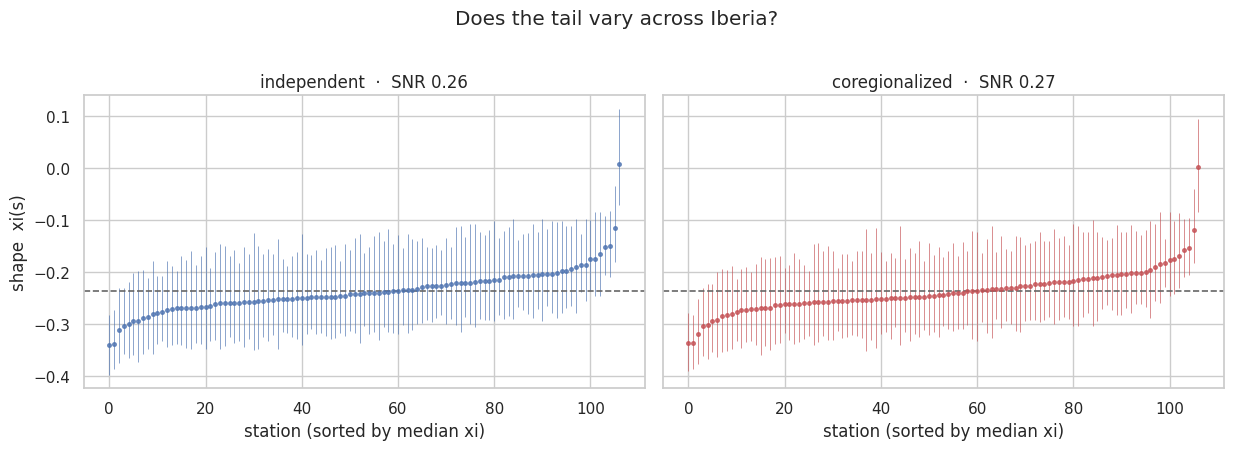

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, kind in zip(axes, ("independent", "coregionalized")):
    xi = fits[kind]["xi_field"]
    med = np.median(xi, 0)
    lo, hi = np.quantile(xi, 0.025, 0), np.quantile(xi, 0.975, 0)
    order = np.argsort(med)
    x = np.arange(S)
    ax.errorbar(x, med[order], yerr=[med[order] - lo[order], hi[order] - med[order]],
                fmt="o", ms=2.6, lw=0.6, alpha=0.75,
                color="#4C72B0" if kind == "independent" else "#C44E52")
    ax.axhline(med.mean(), ls="--", color="0.4", lw=1.2)
    snr, _, _ = xi_snr(xi)
    ax.set(xlabel="station (sorted by median xi)", title=f"{kind}  ·  SNR {snr:.2f}")
axes[0].set_ylabel("shape  xi(s)")
fig.suptitle("Does the tail vary across Iberia?", y=1.02)
fig.tight_layout()
plt.show()

## What the model learned about the sharing

$W$ itself is not identifiable — rotate the latent processes and rotate $W$ the
opposite way and nothing observable changes. What *is* identified is the implied
cross-covariance $B = WW^{\!\top}$, so that is what we report, normalised to
correlations.


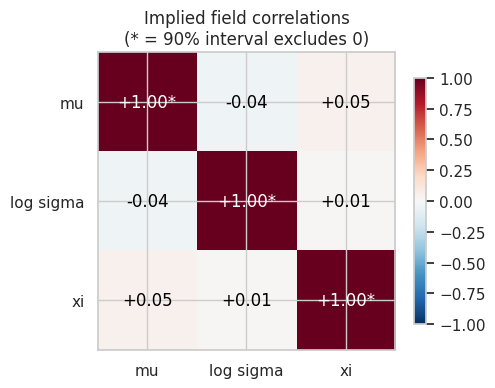

corr(mu       , log sigma) = -0.04  90% (-0.89, +0.90)
corr(mu       , xi       ) = +0.05  90% (-0.89, +0.94)
corr(log sigma, xi       ) = +0.01  90% (-0.89, +0.93)


In [8]:
W = fits["coregionalized"]["W"]                 # (draws, 3, Q)
B = np.einsum("dpq,drq->dpr", W, W)             # (draws, 3, 3)
Dg = np.sqrt(np.einsum("dpp->dp", B))
corr = B / (Dg[:, :, None] * Dg[:, None, :])
corr_med = np.median(corr, 0)
names = ["mu", "log sigma", "xi"]

fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(corr_med, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(3), names); ax.set_yticks(range(3), names)
for i in range(3):
    for j in range(3):
        lo = np.quantile(corr[:, i, j], 0.05)
        hi = np.quantile(corr[:, i, j], 0.95)
        excl = "" if lo < 0 < hi else "*"
        ax.text(j, i, f"{corr_med[i, j]:+.2f}{excl}", ha="center", va="center",
                color="white" if abs(corr_med[i, j]) > 0.55 else "black")
ax.set_title("Implied field correlations\n(* = 90% interval excludes 0)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

for i in range(3):
    for j in range(i + 1, 3):
        lo, hi = np.quantile(corr[:, i, j], [0.05, 0.95])
        print(f"corr({names[i]:9s}, {names[j]:9s}) = {corr_med[i, j]:+.2f}  "
              f"90% ({lo:+.2f}, {hi:+.2f})")

## Real, borrowed — or neither?

The worry going in was that sharing would make $\xi(s)$ *look* more structured
without earning it, since the shape field is now free to borrow from fields the
data constrains well. The checks below were built to catch that.

They caught something else. Look at how closely the two models' shape fields
agree, and at how wide the intervals on the learned correlations are.


ELBO loss  independent 13987.2  |  coregionalized 13982.4  (lower is better)
corr(xi_coreg, mu_coreg)      = -0.20
corr(xi_coreg, xi_independent) = +0.99


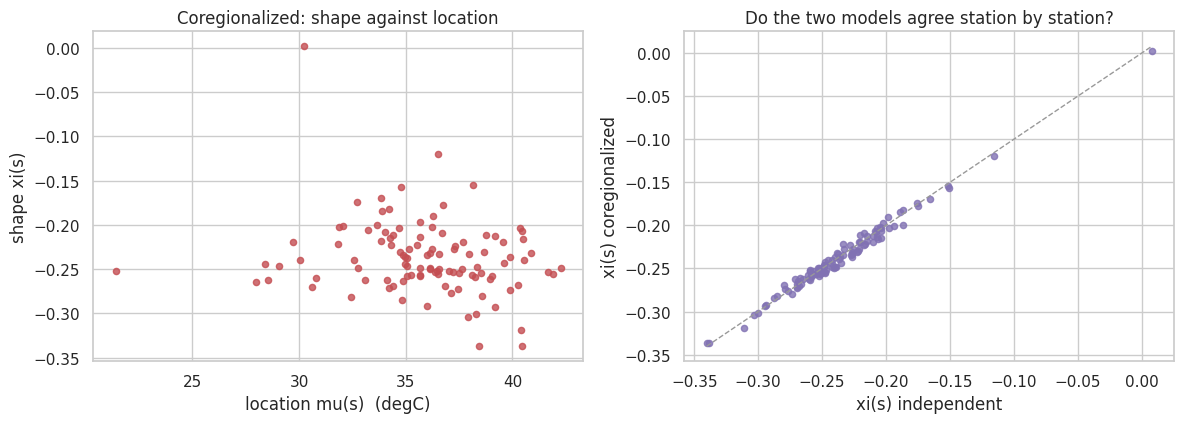

In [9]:
xi_i = np.median(fits["independent"]["xi_field"], 0)
xi_c = np.median(fits["coregionalized"]["xi_field"], 0)
mu_c = np.median(fits["coregionalized"]["mu_field"], 0)

print(f"ELBO loss  independent {fits['independent']['loss']:.1f}"
      f"  |  coregionalized {fits['coregionalized']['loss']:.1f}"
      f"  (lower is better)")
print(f"corr(xi_coreg, mu_coreg)      = {np.corrcoef(xi_c, mu_c)[0, 1]:+.2f}")
print(f"corr(xi_coreg, xi_independent) = {np.corrcoef(xi_c, xi_i)[0, 1]:+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(mu_c, xi_c, s=20, alpha=0.8, color="#C44E52")
axes[0].set(xlabel="location mu(s)  (degC)", ylabel="shape xi(s)",
            title="Coregionalized: shape against location")
axes[1].scatter(xi_i, xi_c, s=20, alpha=0.8, color="#8172B3")
lims = [min(xi_i.min(), xi_c.min()), max(xi_i.max(), xi_c.max())]
axes[1].plot(lims, lims, ls="--", color="0.6", lw=1)
axes[1].set(xlabel="xi(s) independent", ylabel="xi(s) coregionalized",
            title="Do the two models agree station by station?")
fig.tight_layout()
plt.show()

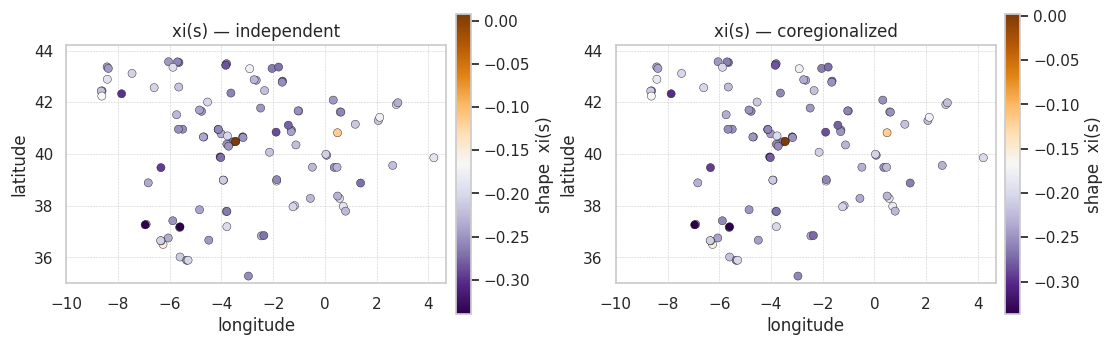

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (vals, title) in zip(axes, [(xi_i, "independent"), (xi_c, "coregionalized")]):
    iberia_axes(ax=ax)
    scatter_field(ax, stations[:, 0], stations[:, 1], vals,
                  label="shape  xi(s)", cmap="PuOr_r", s=34)
    ax.set_title(f"xi(s) — {title}")
plt.show()

## Takeaway

**Coregionalization changed nothing here, and that is the result.**

The shape field's signal-to-noise ratio moved from 0.264 to 0.268 — no change.
The two models' $\xi(s)$ estimates correlate at **0.99**: station by station,
letting the fields share produced the same map the independent model already
had. The ELBO improved by about 5 nats on ~13,985, which for a model carrying an
extra $3\times3$ mixing matrix is not evidence of anything.

**The reason is visible in the correlation panel: $W$ was never identified.**
Every implied field correlation came back near zero with a 90% interval spanning
roughly $(-0.9, +0.9)$ — essentially the prior, unmoved. The likelihood carried
almost no information about *how* the three fields covary. That is a statement
about the data, not about the sampler: 107 stations with a few decades of
maxima each can pin down a location field comfortably, but the cross-field
covariance is a second-order feature of an already weak signal.

So notebook 09's conclusion survives this test. "The tail has no recoverable
geography" was not an artifact of the independence assumption, because relaxing
that assumption did not change the answer. It is worth having established that
directly rather than assuming either way.

**A caution the run itself supplied.** The independent model here — the same
model as notebook 09, fitted the same way — reports an $\xi$ SNR of **0.264**,
where notebook 09 reported **0.13**. Same model, same data, different fit. That
factor of two is not a modelling result; it is the mean-field variational
posterior being unstable across runs, exactly the unreliability notebook 13
measured directly (its posterior spread came in at 0.24x a NUTS reference).
Since the SNR is a spread divided by an interval width, and both come from that
approximation, its absolute value should not be over-read. The comparison
between two models fitted identically in one session is the defensible part;
the cross-notebook comparison to 0.13 is not.

**What would actually test the tail's geography.** Not a richer prior over
fields the data cannot constrain, but more information per station: pooling
across a longer record, a threshold-exceedance likelihood that uses far more of
each series than one maximum per year, or an inference method whose uncertainty
can be trusted at face value — notebook 13's Gauss-Newton being the cheap
candidate.

### Where this leads

The remaining thread from the survey is **pathwise sampling**: return-level maps
that carry joint rather than marginal uncertainty, so one can ask for the
probability that a level is exceeded *somewhere* in a region rather than at each
point independently.
